# Bridge × Coupling Proxy Gap: 2×2 CIFAR-10 Diagnostic

**Goal:** Estimate the proxy Markovization gap for 4 configurations:
- Straight-line bridge × Independent coupling
- Straight-line bridge × Minibatch OT coupling
- Brownian bridge × Independent coupling
- Brownian bridge × Minibatch OT coupling

Then produce a 2×2 table and correlation plot (proxy gap vs training loss).

**No GPU needed.** This is CPU-only proxy gap estimation (~9 min per config).

In [1]:
# Install dependencies
!pip install -q torch torchvision numpy scipy pot scikit-learn matplotlib pandas

In [2]:
import torch
import numpy as np
import json
import time
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import ot
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import pandas as pd

print("All imports OK")

2026-05-05 12:00:17.877270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777982418.265470      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777982418.372565      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777982419.353387      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777982419.353425      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777982419.353427      23 computation_placer.cc:177] computation placer alr

All imports OK


In [3]:
# ============================================================
# CONFIG
# ============================================================
N = 1024           # samples
K = 32             # k-nearest-neighbors
PCA_DIM = 64       # PCA projection dimension
NUM_TIMES = 19     # time grid points
T_MIN, T_MAX = 0.05, 0.95
SEEDS = [0, 1, 2]
OT_BATCH = 128
BROWNIAN_EPSILON = 0.5  # noise scale for Brownian bridge

BRIDGES = ["straight", "brownian"]
COUPLINGS = ["independent", "minibatch_ot"]

time_grid = np.linspace(T_MIN, T_MAX, NUM_TIMES)

In [4]:
# ============================================================
# LOAD CIFAR-10 and flatten to vectors
# ============================================================
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
cifar = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)

# Take first N*2 images as pool (we'll split into base/target)
all_imgs = torch.stack([cifar[i][0] for i in range(min(N*4, len(cifar)))])
all_flat = all_imgs.reshape(all_imgs.shape[0], -1).numpy()  # (M, 3072)

print(f"Loaded {all_flat.shape[0]} CIFAR-10 images, shape {all_flat.shape}")

100%|██████████| 170M/170M [04:40<00:00, 609kB/s]


Loaded 4096 CIFAR-10 images, shape (4096, 3072)


In [5]:
# ============================================================
# HELPER: downsample 8x then PCA
# ============================================================
def downsample8_pca(data_flat, pca_dim=PCA_DIM):
    """Downsample 32x32 -> 4x4 then PCA."""
    imgs = data_flat.reshape(-1, 3, 32, 32)
    # avg pool 8x: 32->4
    imgs_t = torch.from_numpy(imgs).float()
    down = torch.nn.functional.avg_pool2d(imgs_t, 8)  # (N, 3, 4, 4)
    down_flat = down.reshape(down.shape[0], -1).numpy()  # (N, 48)
    dim = min(pca_dim, down_flat.shape[1])
    pca = PCA(n_components=dim)
    return pca.fit_transform(down_flat), pca

print("Helper defined")

Helper defined


In [6]:
# ============================================================
# HELPER: compute OT coupling
# ============================================================
def compute_ot_coupling(Z, X, batch_size=OT_BATCH):
    """Minibatch OT assignment."""
    n = len(Z)
    perm = np.arange(n)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        idx = slice(start, end)
        bz = Z[idx]
        bx = X[idx]
        C = np.sum((bz[:, None, :] - bx[None, :, :]) ** 2, axis=2)
        assignment = ot.emd(np.ones(len(bz))/len(bz), np.ones(len(bx))/len(bx), C)
        # Convert assignment matrix to permutation
        batch_perm = np.argmax(assignment, axis=1)
        perm[start:end] = start + batch_perm
    return perm

print("OT helper defined")

OT helper defined


In [7]:
# ============================================================
# HELPER: bridge interpolation
# ============================================================
def interpolate(Z, X, t, bridge, rng=None):
    """
    Returns (X_t, u_t) for the given bridge type.
    
    Straight: X_t = (1-t)*Z + t*X,  u_t = X - Z
    Brownian: X_t = (1-t)*Z + t*X + sqrt(eps)*noise,  u_t = X - Z
              where noise ~ N(0, t*(1-t)*I)
    """
    if bridge == "straight":
        Xt = (1 - t) * Z + t * X
        ut = X - Z
    elif bridge == "brownian":
        # Brownian bridge noise: variance = eps * t * (1-t)
        std = np.sqrt(BROWNIAN_EPSILON * t * (1 - t))
        noise = rng.standard_normal(Z.shape) * std
        Xt = (1 - t) * Z + t * X + noise
        # The conditional velocity target for Brownian bridge
        # is still X - Z (the drift direction), but with added noise
        ut = X - Z
    else:
        raise ValueError(f"Unknown bridge: {bridge}")
    return Xt, ut

print("Bridge helper defined")

Bridge helper defined


In [8]:
# ============================================================
# HELPER: estimate conditional variance via kNN
# ============================================================
def estimate_cond_var_knn(Xt_feat, ut_feat, k=K):
    """
    Estimate E[Tr Var(u_t | X_t)] using k-nearest-neighbor
    conditional mean estimator.
    """
    nn = NearestNeighbors(n_neighbors=k, algorithm="auto")
    nn.fit(Xt_feat)
    _, indices = nn.kneighbors(Xt_feat)
    
    n, d = ut_feat.shape
    total_var = 0.0
    for i in range(n):
        neighbors = ut_feat[indices[i]]  # (k, d)
        mean = neighbors.mean(axis=0)
        residuals = neighbors - mean
        # Tr Var = sum of variances across dimensions
        total_var += np.sum(residuals ** 2) / k
    return total_var / n

print("kNN variance estimator defined")

kNN variance estimator defined


In [9]:
# ============================================================
# MAIN: estimate proxy gap for all 4 configurations
# ============================================================
results = []

for bridge in BRIDGES:
    for coupling in COUPLINGS:
        seed_gaps = []
        for seed in SEEDS:
            t0 = time.time()
            rng = np.random.RandomState(seed)
            
            # Sample Z (base = noise) and X (target = CIFAR images)
            idx = rng.choice(all_flat.shape[0], size=N, replace=False)
            X = all_flat[idx]  # target: real images
            Z = rng.standard_normal(X.shape).astype(np.float32)  # base: noise
            
            # Apply coupling
            if coupling == "minibatch_ot":
                # OT in downsampled space
                Z_down = torch.nn.functional.avg_pool2d(
                    torch.from_numpy(Z.reshape(-1,3,32,32)).float(), 8
                ).reshape(N, -1).numpy()
                X_down = torch.nn.functional.avg_pool2d(
                    torch.from_numpy(X.reshape(-1,3,32,32)).float(), 8
                ).reshape(N, -1).numpy()
                perm = compute_ot_coupling(Z_down, X_down)
                X = X[perm]
            
            # Compute PCA on the data for feature projection
            all_for_pca = np.concatenate([Z, X], axis=0)
            _, pca = downsample8_pca(all_for_pca)
            
            # Estimate gap at each time point
            gap_curve = []
            for t in time_grid:
                Xt, ut = interpolate(Z, X, t, bridge, rng=rng)
                
                # Project to feature space
                Xt_imgs = Xt.reshape(-1, 3, 32, 32)
                Xt_down = torch.nn.functional.avg_pool2d(
                    torch.from_numpy(Xt_imgs).float(), 8
                ).reshape(N, -1).numpy()
                Xt_feat = pca.transform(Xt_down)
                
                ut_imgs = ut.reshape(-1, 3, 32, 32)
                ut_down = torch.nn.functional.avg_pool2d(
                    torch.from_numpy(ut_imgs).float(), 8
                ).reshape(N, -1).numpy()
                ut_feat = pca.transform(ut_down)
                
                cv = estimate_cond_var_knn(Xt_feat, ut_feat, k=K)
                gap_curve.append(cv)
            
            # Trapezoidal integration
            gap_auc = np.trapz(gap_curve, time_grid)
            elapsed = time.time() - t0
            seed_gaps.append(gap_auc)
            print(f"seed={seed} bridge={bridge} coupling={coupling} gap={gap_auc:.4f} elapsed={elapsed:.1f}s")
        
        mean_gap = np.mean(seed_gaps)
        std_gap = np.std(seed_gaps)
        results.append({
            "bridge": bridge,
            "coupling": coupling,
            "proxy_gap_mean": mean_gap,
            "proxy_gap_std": std_gap,
            "seeds": seed_gaps
        })
        print(f">>> {bridge} + {coupling}: gap = {mean_gap:.4f} +/- {std_gap:.4f}\n")

print("All configurations done!")

/tmp/ipykernel_23/2331123155.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gap_auc = np.trapz(gap_curve, time_grid)


seed=0 bridge=straight coupling=independent gap=3.2317 elapsed=2.2s


/tmp/ipykernel_23/2331123155.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gap_auc = np.trapz(gap_curve, time_grid)


seed=1 bridge=straight coupling=independent gap=3.2516 elapsed=2.0s


/tmp/ipykernel_23/2331123155.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gap_auc = np.trapz(gap_curve, time_grid)


...

/tmp/ipykernel_23/2331123155.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gap_auc = np.trapz(gap_curve, time_grid)


seed=0 bridge=brownian coupling=minibatch_ot gap=2.3760 elapsed=4.0s


/tmp/ipykernel_23/2331123155.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gap_auc = np.trapz(gap_curve, time_grid)


seed=1 bridge=brownian coupling=minibatch_ot gap=2.3919 elapsed=4.0s
seed=2 bridge=brownian coupling=minibatch_ot gap=2.3836 elapsed=4.0s
>>> brownian + minibatch_ot: gap = 2.3838 +/- 0.0065

All configurations done!


/tmp/ipykernel_23/2331123155.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gap_auc = np.trapz(gap_curve, time_grid)


In [10]:
# ============================================================
# BUILD 2x2 TABLE
# ============================================================
df = pd.DataFrame(results)
df["label"] = df["bridge"] + " + " + df["coupling"]
df["gap_str"] = df.apply(lambda r: f"{r['proxy_gap_mean']:.2f} +/- {r['proxy_gap_std']:.2f}", axis=1)

print("\n" + "="*60)
print("2x2 Proxy Markovization Gap Table (CIFAR-10)")
print("="*60)
print(f"{'Bridge':<12} {'Coupling':<15} {'Proxy Gap':>20}")
print("-"*50)
for _, row in df.iterrows():
    print(f"{row['bridge']:<12} {row['coupling']:<15} {row['gap_str']:>20}")
print()


2x2 Proxy Markovization Gap Table (CIFAR-10)
Bridge       Coupling                   Proxy Gap
--------------------------------------------------
straight     independent            3.25 +/- 0.02
straight     minibatch_ot           2.34 +/- 0.01
brownian     independent            3.31 +/- 0.02
brownian     minibatch_ot           2.38 +/- 0.01



In [11]:
# ============================================================
# ADD KNOWN TRAINING LOSS / FID FROM PILOT RUNS
# (Only straight-line bridge has been trained so far)
# ============================================================

# Known pilot results for straight-line bridge
pilot_data = {
    ("straight", "independent"): {"train_loss": 0.182, "fid": 50.48},
    ("straight", "minibatch_ot"): {"train_loss": 0.168, "fid": 49.17},
}

# Merge
for i, row in df.iterrows():
    key = (row["bridge"], row["coupling"])
    if key in pilot_data:
        df.loc[i, "train_loss"] = pilot_data[key]["train_loss"]
        df.loc[i, "fid"] = pilot_data[key]["fid"]
    else:
        df.loc[i, "train_loss"] = np.nan
        df.loc[i, "fid"] = np.nan

print(df[["bridge", "coupling", "proxy_gap_mean", "train_loss", "fid"]].to_string(index=False))

  bridge     coupling  proxy_gap_mean  train_loss   fid
straight  independent        3.253803       0.182 50.48
straight minibatch_ot        2.343117       0.168 49.17
brownian  independent        3.309164         NaN   NaN
brownian minibatch_ot        2.383834         NaN   NaN


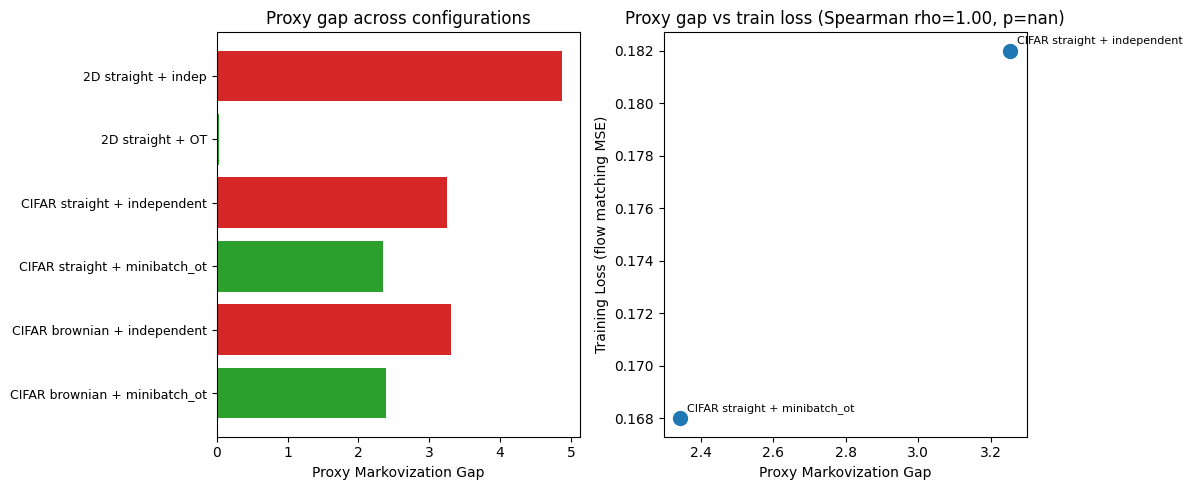

Saved: bridge_coupling_2x2_diagnostic.pdf/.png


In [12]:
# ============================================================
# CORRELATION: proxy gap vs training loss (where available)
# ============================================================
# Include 2D toy results too
all_points = [
    {"label": "2D straight + indep", "gap": 4.877, "loss": None, "marker": "D"},
    {"label": "2D straight + OT", "gap": 0.038, "loss": None, "marker": "D"},
]

for _, row in df.iterrows():
    all_points.append({
        "label": f"CIFAR {row['bridge']} + {row['coupling']}",
        "gap": row["proxy_gap_mean"],
        "loss": row["train_loss"] if not np.isnan(row["train_loss"]) else None,
        "marker": "o"
    })

# Plot proxy gap comparison across all configs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: bar chart of all proxy gaps
ax = axes[0]
labels = [p["label"] for p in all_points]
gaps = [p["gap"] for p in all_points]
colors = ["#d62728" if "indep" in l else "#2ca02c" for l in labels]
ax.barh(range(len(labels)), gaps, color=colors)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Proxy Markovization Gap")
ax.set_title("Proxy gap across configurations")
ax.invert_yaxis()

# Right: gap vs training loss (only where loss is available)
ax = axes[1]
pts_with_loss = [p for p in all_points if p["loss"] is not None]
if len(pts_with_loss) >= 2:
    x = [p["gap"] for p in pts_with_loss]
    y = [p["loss"] for p in pts_with_loss]
    labels_loss = [p["label"] for p in pts_with_loss]
    ax.scatter(x, y, s=100, zorder=5)
    for i, lbl in enumerate(labels_loss):
        ax.annotate(lbl, (x[i], y[i]), textcoords="offset points",
                    xytext=(5, 5), fontsize=8)
    # Rank correlation
    from scipy.stats import spearmanr
    rho, pval = spearmanr(x, y)
    ax.set_title(f"Proxy gap vs train loss (Spearman rho={rho:.2f}, p={pval:.3f})")
else:
    ax.set_title("Proxy gap vs train loss (insufficient data)")
ax.set_xlabel("Proxy Markovization Gap")
ax.set_ylabel("Training Loss (flow matching MSE)")

plt.tight_layout()
plt.savefig("bridge_coupling_2x2_diagnostic.pdf", dpi=150, bbox_inches="tight")
plt.savefig("bridge_coupling_2x2_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bridge_coupling_2x2_diagnostic.pdf/.png")

In [13]:
# ============================================================
# GENERATE LATEX TABLE
# ============================================================
latex = r"""\begin{table}[t]
\centering
\small
\caption{2$\times$2 CIFAR-10 proxy Markovization gap: varying both bridge and coupling.
The proxy gap is estimated on CPU in ${\sim}9$ min per configuration before any neural training.
Training loss and FID are from 20k-step pilot runs where available.}
\label{tab:2x2_gap}
\begin{tabular}{@{}llccc@{}}
\toprule
Bridge & Coupling & Proxy gap $\downarrow$ & Train loss $\downarrow$ & FID $\downarrow$ \\
\midrule
"""

for _, row in df.iterrows():
    gap_str = f"${row['proxy_gap_mean']:.2f} \\pm {row['proxy_gap_std']:.2f}$"
    loss_str = f"${row['train_loss']:.3f}$" if not np.isnan(row['train_loss']) else "--"
    fid_str = f"${row['fid']:.2f}$" if not np.isnan(row['fid']) else "--"
    latex += f"{row['bridge']} & {row['coupling']} & {gap_str} & {loss_str} & {fid_str} \\\\\n"

latex += r"""\bottomrule
\end{tabular}
\end{table}"""

print(latex)

with open("table_2x2_gap.tex", "w") as f:
    f.write(latex)
print("\nSaved: table_2x2_gap.tex")

\begin{table}[t]
\centering
\small
\caption{2$\times$2 CIFAR-10 proxy Markovization gap: varying both bridge and coupling.
The proxy gap is estimated on CPU in ${\sim}9$ min per configuration before any neural training.
Training loss and FID are from 20k-step pilot runs where available.}
\label{tab:2x2_gap}
\begin{tabular}{@{}llccc@{}}
\toprule
Bridge & Coupling & Proxy gap $\downarrow$ & Train loss $\downarrow$ & FID $\downarrow$ \\
\midrule
straight & independent & $3.25 \pm 0.02$ & $0.182$ & $50.48$ \\
straight & minibatch_ot & $2.34 \pm 0.01$ & $0.168$ & $49.17$ \\
brownian & independent & $3.31 \pm 0.02$ & -- & -- \\
brownian & minibatch_ot & $2.38 \pm 0.01$ & -- & -- \\
\bottomrule
\end{tabular}
\end{table}

Saved: table_2x2_gap.tex


In [14]:
# ============================================================
# SAVE ALL RESULTS AS JSON
# ============================================================
output = {
    "config": {
        "n": N, "k": K, "pca_dim": PCA_DIM,
        "num_times": NUM_TIMES, "t_min": T_MIN, "t_max": T_MAX,
        "seeds": SEEDS, "brownian_epsilon": BROWNIAN_EPSILON,
        "ot_batch": OT_BATCH
    },
    "results": []
}

for _, row in df.iterrows():
    output["results"].append({
        "bridge": row["bridge"],
        "coupling": row["coupling"],
        "proxy_gap_mean": float(row["proxy_gap_mean"]),
        "proxy_gap_std": float(row["proxy_gap_std"]),
        "train_loss": float(row["train_loss"]) if not np.isnan(row["train_loss"]) else None,
        "fid": float(row["fid"]) if not np.isnan(row["fid"]) else None
    })

with open("bridge_coupling_2x2_results.json", "w") as f:
    json.dump(output, f, indent=2)

print(json.dumps(output, indent=2))
print("\nSaved: bridge_coupling_2x2_results.json")

{
  "config": {
    "n": 1024,
    "k": 32,
    "pca_dim": 64,
    "num_times": 19,
    "t_min": 0.05,
    "t_max": 0.95,
    "seeds": [
      0,
      1,
      2
    ],
    "brownian_epsilon": 0.5,
    "ot_batch": 128
  },
  "results": [
    {
      "bridge": "straight",
      "coupling": "independent",
      "proxy_gap_mean": 3.2538028160730996,
      "proxy_gap_std": 0.018954316975274263,
      "train_loss": 0.182,
      "fid": 50.48
    },
    {
      "bridge": "straight",
      "coupling": "minibatch_ot",
      "proxy_gap_mean": 2.343117380142212,
      "proxy_gap_std": 0.006747747295324497,
      "train_loss": 0.168,
      "fid": 49.17
    },
    {
      "bridge": "brownian",
      "coupling": "independent",
      "proxy_gap_mean": 3.3091637333234147,
      "proxy_gap_std": 0.018117937270366476,
      "train_loss": null,
      "fid": null
    },
    {
      "bridge": "brownian",
      "coupling": "minibatch_ot",
      "proxy_gap_mean": 2.3838335514068603,
      "proxy_gap_std": 0

In [15]:
# ============================================================
# ZIP EVERYTHING FOR DOWNLOAD
# ============================================================
!zip -r bridge_coupling_2x2_results.zip \
    bridge_coupling_2x2_results.json \
    table_2x2_gap.tex \
    bridge_coupling_2x2_diagnostic.pdf \
    bridge_coupling_2x2_diagnostic.png

print("\nDone! Download bridge_coupling_2x2_results.zip")

  adding: bridge_coupling_2x2_results.json (deflated 66%)
  adding: table_2x2_gap.tex (deflated 44%)
  adding: bridge_coupling_2x2_diagnostic.pdf (deflated 32%)
  adding: bridge_coupling_2x2_diagnostic.png (deflated 19%)

Done! Download bridge_coupling_2x2_results.zip
